Utilizzando il dataset Breast Cancer, replicare l'esercitazione
- Effettuare lo split dei dati con test_set=0.2 e shuffle=True e stratify=y
- Effettuare la standarizzazione di train e test set
- Allenare un SVC con kernel='linear', C=1.0, epsilon=0.1
- Creare una griglia di parametri e avviare una Grid Search, al termine stampare i valori dei parametri e l'accuracy
- Risurre il dataset scalalto con PCA n_components=2
- Subplottare i decision boundary colorati e i dati colorati in a base alle loro reali etichette

SVC → classificazione → y = categorie
SVR → regressione → y = numero continuo

In questo dataset ho classi (es. 0/1, oppure iris 1,2,3)
quindi devo fare classificazione ed usare SVC, mentre SVR e make_regression sono per regressione (numero continuo)

X = caratteristiche numeriche del tumore
y = classe da prevedere: maligno (0), benigno (1)

Questo è un problema di classificazione, non di regressione.

In [25]:
import numpy as np
from sklearn.svm import SVC
import pandas as pd
import matplotlib.pylab as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV

Utilizzando il dataset Breast Cancer, replicare l'esercitazione

In [18]:
data=load_breast_cancer()
X=data.data
y=data.target
feature_names=data.feature_names


print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Classi:", data.target_names)

df=pd.DataFrame(X,columns=data.feature_names)
df["target"]=y
display(df)
#df["target"].value_counts()  #ho anche valori nulli
df.groupby("target").count()  #conta i valori non nulli per colonna
df.groupby("target").mean()  #conta i valori non nulli per colonna

Shape X: (569, 30)
Shape y: (569,)
Classi: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
target,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


- Effettuare lo split dei dati con test_set=0.2 e shuffle=True e stratify=y

stratity=y per mantenere la stessa proporzione tra le classi

Con SVC lo scaling dei dati è obbligatorio

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,shuffle=True,random_state=42,test_size=0.2)

- Effettuare la standarizzazione di train e test set

In [20]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

- Allenare un SVC con kernel='linear', C=1.0, epsilon=0.1

Modello SVC di default

In [ ]:
model_default=SVC(random_state=42,kernel="linear",C=1.0)
model_default.fit(X_train_scaled,y_train)
y_pred_default=model_default.predict(X_test_scaled)

acc_defaul=accuracy_score(y_test,y_pred_default)
print(f"Parametri default:\n{model_default.get_params()}")

Parametri default:
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


- Creare una griglia di parametri e avviare una Grid Search, al termine stampare i valori dei parametri e l'accuracy

Modello ottimizzato con GridSearchCV

In [23]:
param_grid={'C':[0.1,1,10],'kernel':['linear','rbf'],'gamma':['scale','auto']} #dizionario param grid

grid_search= GridSearchCV(SVC(random_state=42),param_grid=param_grid,cv=5)
grid_search.fit(X_train_scaled,y_train)

best_model=grid_search.best_estimator_
y_pred_best=best_model.predict(X_test_scaled)

acc_best=accuracy_score(y_test,y_pred_best)

In [24]:
print(f"Parametri default:\n{model_default.get_params()}")
print(f"Migliori parametri:\n{grid_search.best_params_}")
print(f"Accuracy (default):\t{acc_defaul*100:.2f}%")
print(f"Accuracy (best):\t{acc_best*100:.2f}%")

Parametri default:
{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Migliori parametri:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (default):	97.37%
Accuracy (best):	98.25%


In [26]:
print("\nClassification Report - Default")
print(classification_report(y_test, y_pred_default, target_names=data.target_names))

print("\nClassification Report - Tuned")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))


Classification Report - Default
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Classification Report - Tuned
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Accuracy default: 97%
Accuract Tunes: 98%
Miglioramenti piccolo ma reale

In [30]:
cm_default = confusion_matrix(y_test, y_pred_default)
cm_best = confusion_matrix(y_test, y_pred_best)

print("\nConfusion Matrix - Default - (TN=Veri negativi FP=Falsi positivi FN=Falsi negativi TP=Veri positivi)")
print(cm_default)

print("\nConfusion Matrix - Tuned - (TN=Veri negativi FP=Falsi positivi FN=Falsi negativi TP=Veri positivi)")
print(cm_best)


Confusion Matrix - Default - (TN=Veri negativi FP=Falsi positivi FN=Falsi negativi TP=Veri positivi)
[[41  1]
 [ 2 70]]

Confusion Matrix - Tuned - (TN=Veri negativi FP=Falsi positivi FN=Falsi negativi TP=Veri positivi)
[[41  1]
 [ 1 71]]


Errori totali = FP + FN = 1 + 2 = 3
Il modello sbaglia poco (3 volte su tutti i casi) ma sbaglia, ci sono 3 falsi negativi con il modello di default, 2 falsi negativo con il modello ottimizzato (comunque grave in ambito medico)

Precision = TP / (TP+FP) = 98.6% Quando il modello dice positivo ha ragione 98.6% delle volte
Recal = TP / (TP + FN)= 98.6%, Il modello riesce a trovare il 98.6% dei positivi reali

Il modello ottimizzato tramite GridSearch migliora leggermente l'accuray, mantiene stabile il numero di falsi positivi, ma riduce i falsi negativi (errore critico in ambito medico)

il dataset ha 30 features, pertanto se voglio fare un grafico devo ridurre a 2 dimensioni, per esempio con PCA

- Risurre il dataset scalalto con PCA n_components=2

In [28]:
X_scaled=scaler.fit_transform(X)
X_pca=PCA(n_components=2).fit_transform(X_scaled)

#riaddestro i modelli con tutto il dataset scalato
model_default.fit(X_pca,y)
best_model.fit(X_pca,y)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Alleno i due modelli su dati ridotti a 2 componenti

In [29]:
model_default_pca=SVC(random_state=42)
model_default_pca.fit(X_pca,y)

best_model_pca=SVC(**grid_search.best_params_,random_state=42)   # svc creato con i valori della grid search
best_model_pca.fit(X_pca,y)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


- Subplottare i decision boundary colorati e i dati colorati in a base alle loro reali etichette

In [15]:
def plot_decision_boundary(ax, X, y, model, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")


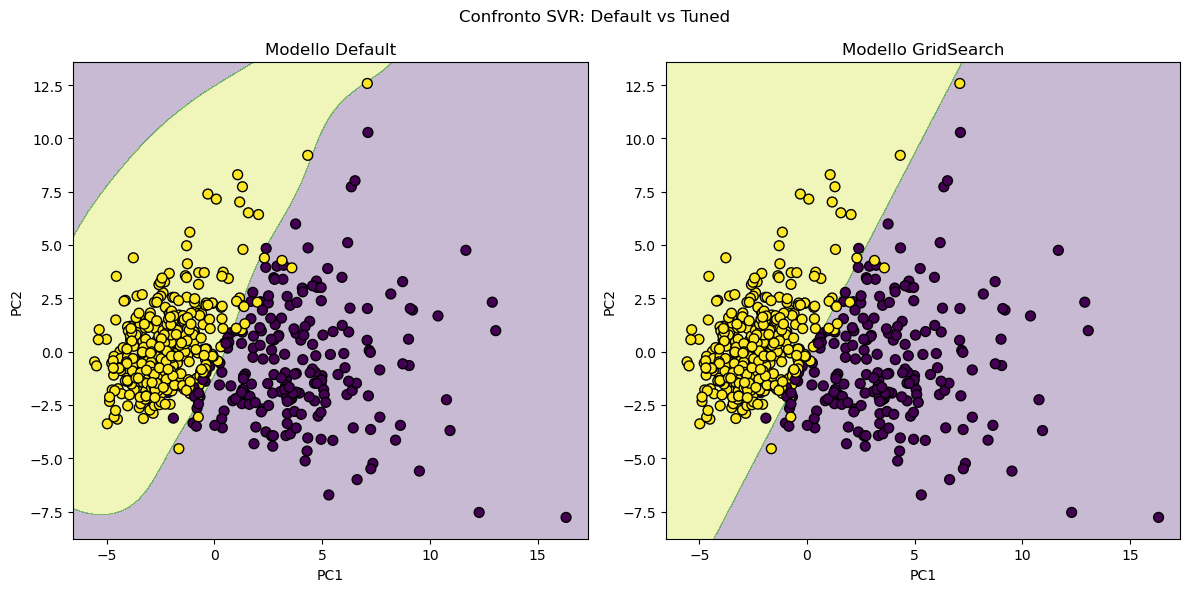

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_decision_boundary(axes[0], X_pca, y, model_default_pca, "Modello Default")
plot_decision_boundary(axes[1], X_pca, y, best_model_pca, "Modello GridSearch")
plt.suptitle("Confronto SVR: Default vs Tuned")
plt.tight_layout()
plt.show()